In [177]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

In [179]:
df = yf.download('JAYNECOIND.NS', start='2025-01-01', end='2026-01-31')['Close']

[*********************100%***********************]  1 of 1 completed


In [181]:
log_returns = np.log(df/df.shift(1)).dropna()
log_returns

Ticker,JAYNECOIND.NS
Date,
2025-01-02,-0.005008
2025-01-03,0.084896
2025-01-06,-0.062803
2025-01-07,0.018969
2025-01-08,0.001925
...,...
2026-01-23,-0.033934
2026-01-27,0.005296
2026-01-28,0.039253


In [215]:
log_returns.mean()

Ticker
JAYNECOIND.NS    0.002246
dtype: float64

In [217]:
log_returns.std()

Ticker
JAYNECOIND.NS    0.043231
dtype: float64

In [221]:
#This iloc[-1] will give you the latest stock price. Similarly iloc[-51] will give you the price of currenct day minus 51th day price

initial = df.iloc[-1].iloc[0]

# Geometric Brownian Motion (GBM Monte Carlo simulation)

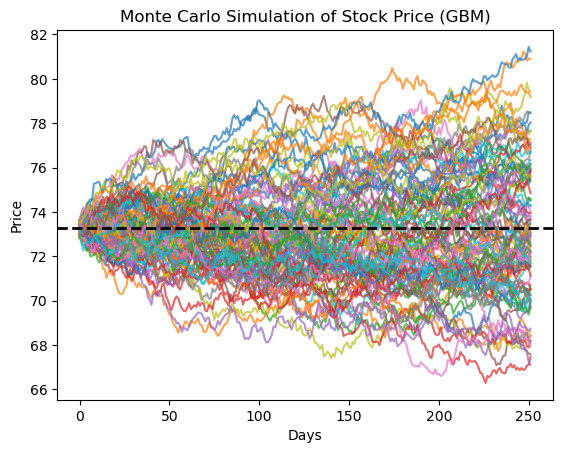

In [267]:
years = 1
T = 252*years
dt = 1 / 252
paths = 100

mu = log_returns.mean()
sigma = log_returns.std()

for i in range(paths):
    shocks = np.random.normal(
        (mu - 0.5 * sigma**2) * dt,
        sigma * np.sqrt(dt),
        T)
    prices = initial * np.exp(np.cumsum(shocks))
    plt.plot(prices, alpha=0.7)

plt.axhline(initial, color='black', linestyle='--', linewidth=2)
plt.title("Monte Carlo Simulation of Stock Price (GBM)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()